In [1]:
from statsmodels.tsa.stattools import adfuller

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/market_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Ticker", "Date"])

df.head()

,Date,Close,High,Low,Open,Volume,Ticker
2888,2015-01-02,59.205643,59.234297,59.040882,59.048047,2218800,BND
2889,2015-01-05,59.377594,59.399083,59.241487,59.270142,5820100,BND
2890,2015-01-06,59.549515,59.728600,59.477882,59.477882,3887600,BND
2891,2015-01-07,59.585320,59.656953,59.492197,59.556665,2433400,BND
2892,2015-01-08,59.492184,59.535162,59.434875,59.535162,1873400,BND


In [3]:
df["Daily_Return"] = df.groupby("Ticker")["Close"].pct_change()

In [4]:
def adf_test(series, name):
    result = adfuller(series.dropna())

    print("\n" + "="*50)
    print(f"ADF TEST: {name}")
    print("="*50)

    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")

    for key, value in result[4].items():
        print(f"Critical Value {key}: {value}")

    if result[1] <= 0.05:
        print("👉 RESULT: Stationary ✅")
    else:
        print("👉 RESULT: Non-Stationary ❌")

In [5]:
for ticker in ["TSLA", "SPY", "BND"]:
    series = df[df["Ticker"] == ticker]["Close"]
    adf_test(series, f"{ticker} - Close Price")


ADF TEST: TSLA - Close Price
ADF Statistic: -1.0695991394177469
p-value: 0.7270419411549218
Critical Value 1%: -3.432638524105552
Critical Value 5%: -2.8625511137463935
Critical Value 10%: -2.567308245513228
👉 RESULT: Non-Stationary ❌

ADF TEST: SPY - Close Price
ADF Statistic: 1.3089435801493554
p-value: 0.996658545157695
Critical Value 1%: -3.4326241980933294
Critical Value 5%: -2.8625447866555227
Critical Value 10%: -2.567304877006608
👉 RESULT: Non-Stationary ❌

ADF TEST: BND - Close Price
ADF Statistic: -1.0478698984113666
p-value: 0.7354071572882624
Critical Value 1%: -3.432627366129768
Critical Value 5%: -2.862546185823105
Critical Value 10%: -2.567305621914905
👉 RESULT: Non-Stationary ❌


 ADF TEST INTERPRETATION (Closing Prices)
 1. TSLA (Tesla)
ADF Statistic: -1.07
p-value: 0.727
Interpretation:
p-value is much greater than 0.05
We fail to reject the null hypothesis
TSLA closing prices are non-stationary
 Meaning:

TSLA has a strong trend over time
Its mean and variance change over time
This is typical for high-growth stocks
2. SPY (S&P 500 ETF)
ADF Statistic: 1.31
p-value: 0.996
Interpretation:
Extremely high p-value → very strong non-stationarity
SPY follows a clear long-term upward trend

Meaning:

Broad market index grows over time
Strong trend = non-stationary series
Not suitable for ARIMA without transformation
3. BND (Bond ETF)
ADF Statistic: -1.05
p-value: 0.735
Interpretation:
Also non-stationary
Even stable bond ETFs show gradual trends over time
 Meaning:

Interest rate changes and bond pricing trends affect long-term behavior
Still not stationary

## Stationarity Test (ADF Results)

The Augmented Dickey-Fuller (ADF) test was applied to the closing prices of TSLA, SPY, and BND to assess stationarity.

The results show that all three assets have p-values significantly greater than 0.05, indicating failure to reject the null hypothesis of non-stationarity. This confirms that the price series contain trends and their statistical properties, such as mean and variance, change over time.

TSLA exhibits non-stationarity due to strong growth and volatility characteristics. SPY shows a strong upward trend reflecting long-term market growth. BND also demonstrates non-stationarity due to macroeconomic and interest rate effects.

These results imply that raw price data is not suitable for ARIMA modeling. Therefore, differencing must be applied to transform the series into a stationary form before forecasting.

In [6]:
for ticker in ["TSLA", "SPY", "BND"]:
    series = df[df["Ticker"] == ticker]["Daily_Return"]
    adf_test(series, f"{ticker} - Daily Returns")


ADF TEST: TSLA - Daily Returns
ADF Statistic: -53.97189280425144
p-value: 0.0
Critical Value 1%: -3.4326178883893763
Critical Value 5%: -2.862541999961805
Critical Value 10%: -2.567303393388591
👉 RESULT: Stationary ✅

ADF TEST: SPY - Daily Returns
ADF Statistic: -17.572181203923343
p-value: 4.046307933438897e-30
Critical Value 1%: -3.4326241980933294
Critical Value 5%: -2.8625447866555227
Critical Value 10%: -2.567304877006608
👉 RESULT: Stationary ✅

ADF TEST: BND - Daily Returns
ADF Statistic: -15.221188310904653
p-value: 5.482342788441695e-28
Critical Value 1%: -3.432627366129768
Critical Value 5%: -2.862546185823105
Critical Value 10%: -2.567305621914905
👉 RESULT: Stationary ✅


ADF TEST INTERPRETATION (Daily Returns)
1. TSLA (Tesla)
ADF Statistic: -53.97
p-value: 0.0
Interpretation:
p-value < 0.05 → reject null hypothesis
The series is strongly stationary

 Meaning:

TSLA returns fluctuate around a stable mean
No long-term trend in returns
Suitable for volatility modeling
2. SPY (S&P 500 ETF)
ADF Statistic: -17.57
p-value: ~ 4e-30
Interpretation:
Strong evidence of stationarity
Returns behave consistently over time

 Meaning:

Market returns are mean-reverting
Suitable for forecasting risk and portfolio behavior
3. BND (Bond ETF)
ADF Statistic: -15.22
p-value: ~ 5e-28
Interpretation:
Strongly stationary series
Very stable return behavior

 Meaning:

Bond returns are low volatility and predictable in distribution
Ideal for risk reduction in portfolios
## Stationarity Test (Daily Returns)

The Augmented Dickey-Fuller (ADF) test was applied to the daily returns of TSLA, SPY, and BND. The results show that all return series are strongly stationary, with p-values effectively equal to zero.

This indicates that daily returns fluctuate around a constant mean and do not exhibit long-term trends. Unlike price series, return series have stable statistical properties over time, making them suitable for time series modeling and volatility analysis.

The stationarity of returns confirms their suitability for financial modeling tasks such as risk estimation, portfolio optimization, and volatility forecasting. This contrasts with raw price data, which was previously found to be non-stationary and therefore unsuitable for direct ARIMA modeling without transformation.

In [7]:
tsla = df[df["Ticker"] == "TSLA"].copy()

tsla = tsla.sort_values("Date")

tsla["Daily_Return"] = tsla["Close"].pct_change()

tsla = tsla.dropna()

In [8]:
var_95 = tsla["Daily_Return"].quantile(0.05)

var_99 = tsla["Daily_Return"].quantile(0.01)

print("VaR 95%:", var_95)
print("VaR 99%:", var_99)

VaR 95%: -0.05166375515284548
VaR 99%: -0.08990644871169305


In [9]:
mean_return = tsla["Daily_Return"].mean()
std_return = tsla["Daily_Return"].std()

sharpe_ratio = mean_return / std_return

print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: 0.050044827310504


 Value at Risk (VaR) Interpretation
 VaR 95% = -0.0517

 Meaning:
On a “normal bad day”, TSLA can lose up to 5.17%
95% of the time, losses are better than this
 VaR 99% = -0.0899

Meaning:

In extreme conditions, TSLA can lose up to 8.99% in a single day
These are rare but severe market shocks
Financial Insight
TSLA has significant downside risk
Tail risk (extreme loss risk) is high
This is typical for high-growth tech stocks

 Conclusion:

TSLA is highly exposed to extreme market movements, especially during crisis periods.

2. Sharpe Ratio Interpretation
 Sharpe = 0.05

Meaning:

Very low risk-adjusted return
Returns are only slightly higher than risk taken

## Risk Metrics Analysis (TSLA)

The Value at Risk (VaR) analysis indicates that TSLA has a 5% daily loss threshold of approximately -5.17%, and a 1% extreme loss threshold of approximately -8.99%. This suggests that the asset is exposed to significant downside risk, particularly during market stress conditions.

The Sharpe Ratio of 0.05 indicates very low risk-adjusted returns, meaning that the returns generated by TSLA are not sufficient to compensate for its high volatility.

Overall, TSLA exhibits a high-risk, high-volatility profile with limited efficiency in risk-adjusted performance. While it offers potential for strong gains, the magnitude of its fluctuations reduces its attractiveness from a risk-adjusted investment perspective.

In [10]:
tsla = df[df["Ticker"] == "TSLA"].copy()

tsla = tsla.sort_values("Date")

tsla.head()

,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return
0,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000,TSLA,NaN
1,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500,TSLA,-0.042041
2,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500,TSLA,0.005664
3,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000,TSLA,-0.001562
4,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500,TSLA,-0.001564


In [11]:
tsla = tsla[["Date", "Close"]]
tsla.set_index("Date", inplace=True)

tsla.head()

,Close
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


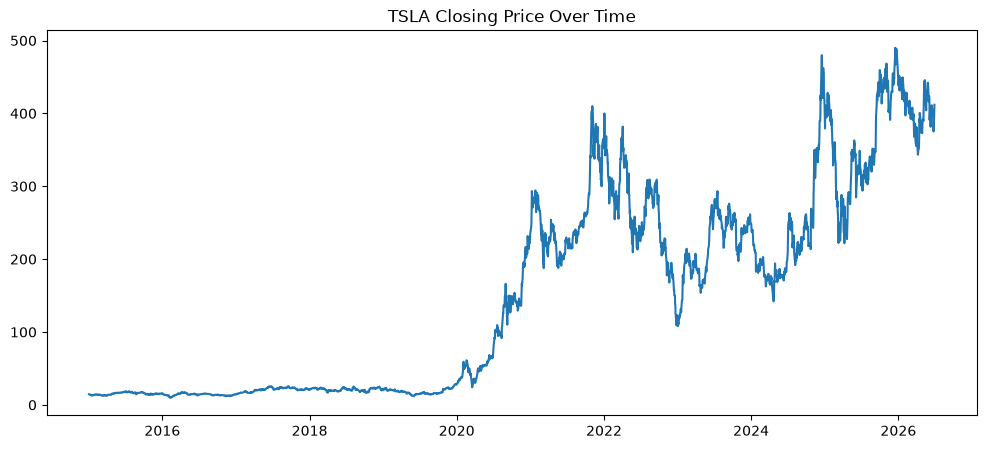

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(tsla["Close"])
plt.title("TSLA Closing Price Over Time")
plt.show()


Train: 2015 → 2024
Test: 2025 → 2026

In [13]:
tsla = df[df["Ticker"] == "TSLA"].copy()
tsla["Date"] = pd.to_datetime(tsla["Date"])
tsla = tsla.sort_values("Date")
tsla = tsla.drop_duplicates("Date")
tsla = tsla.set_index("Date")

In [14]:
tsla = tsla.asfreq("B")   # business days
tsla["Close"] = tsla["Close"].interpolate()

In [15]:
train = tsla.loc["2015-01-01":"2024-12-31"]
test  = tsla.loc["2025-01-01":"2026-06-30"]

In [16]:
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2608
Test size: 389


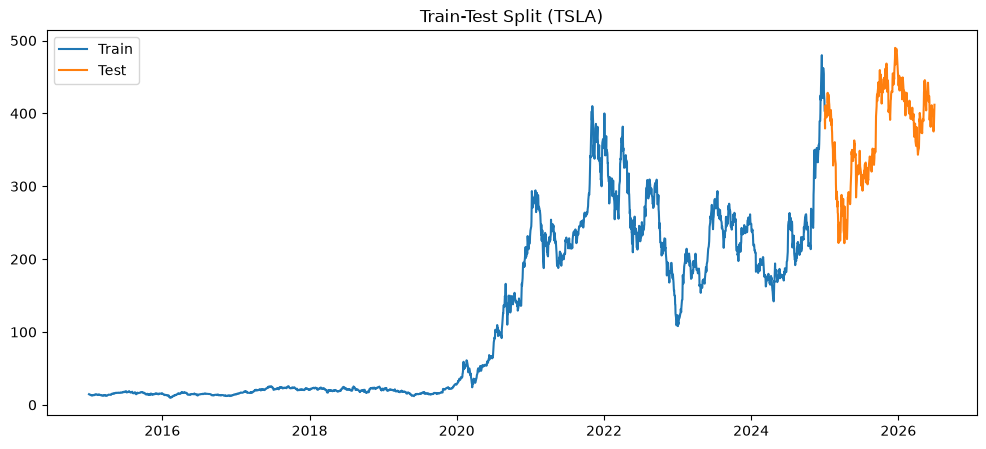

In [17]:
plt.figure(figsize=(12,5))

plt.plot(train["Close"], label="Train")
plt.plot(test["Close"], label="Test")

plt.legend()
plt.title("Train-Test Split (TSLA)")
plt.show()

Time series data must be split chronologically to preserve temporal dependencies. Random shuffling would introduce future information into the training set, leading to data leakage and unrealistic model performance.

Therefore, the dataset was split into:
- Training set: 2015–2024
- Testing set: 2025–2026

<Figure size 1200x400 with 0 Axes>

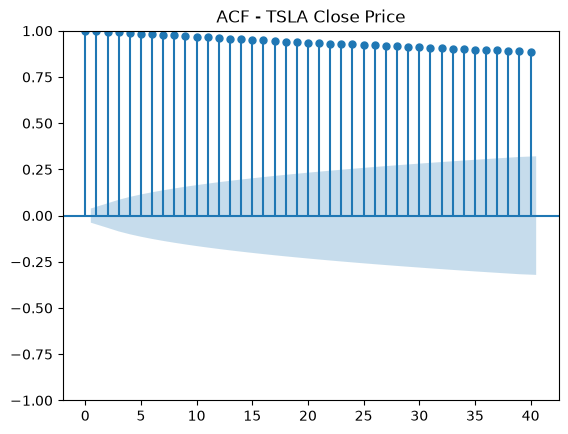

<Figure size 1200x400 with 0 Axes>

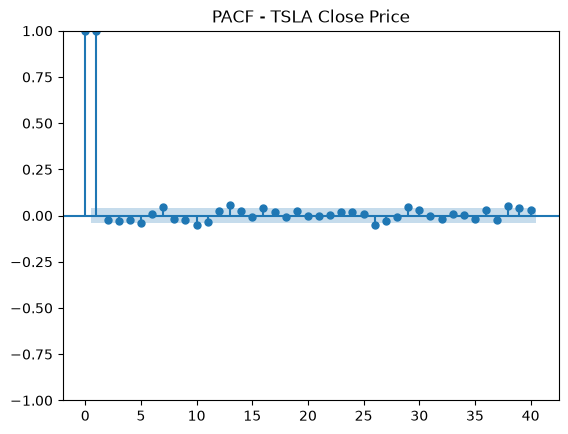

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,4))
plot_acf(train["Close"], lags=40)
plt.title("ACF - TSLA Close Price")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(train["Close"], lags=40)
plt.title("PACF - TSLA Close Price")
plt.show()

In [19]:
from pmdarima import auto_arima

model_auto = auto_arima(
    train["Close"],
    seasonal=False,
    stepwise=True,
    trace=True,
    suppress_warnings=True
)

print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16800.232, Time=0.87 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16825.099, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16827.033, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16827.035, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16824.664, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=16826.994, Time=0.37 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=16827.330, Time=0.50 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=16799.652, Time=1.08 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=16826.022, Time=0.54 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=16801.197, Time=1.51 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=16803.770, Time=1.08 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=16799.750, Time=0.98 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=16821.105, Time=0.81 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=16800.597, Time=1.54 sec
 ARIMA(3,1,2)(0,0,0

In [20]:
!pip install pmdarima

In [21]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train["Close"], order=model_auto.order)
arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2608
Model:                 ARIMA(3, 1, 2)   Log Likelihood               -8393.626
Date:                Mon, 06 Jul 2026   AIC                          16799.253
Time:                        12:16:36   BIC                          16834.448
Sample:                    01-02-2015   HQIC                         16812.003
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3810      0.032    -43.369      0.000      -1.443      -1.319
ar.L2         -0.8331      0.033    -25.079      0.000      -0.898      -0.768
ar.L3         -0.0348      0.012     -2.881      0.0

In [22]:
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast = np.array(arima_forecast, dtype=float)

In [23]:
forecast = model_fit.get_forecast(steps=len(test))
forecast = forecast.predicted_mean

NameError: name 'model_fit' is not defined

In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_model = SARIMAX(
    train["Close"],
    order=model_auto.order,
    seasonal_order=(1,1,1,5)
)

sarima_fit = sarima_model.fit()

c:\Users\cbe\Desktop\portfolio-optimization\.venv311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\cbe\Desktop\portfolio-optimization\.venv311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\cbe\Desktop\portfolio-optimization\.venv311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [25]:
sarima_forecast = sarima_fit.forecast(steps=len(test))
sarima_forecast = np.array(sarima_forecast, dtype=float)

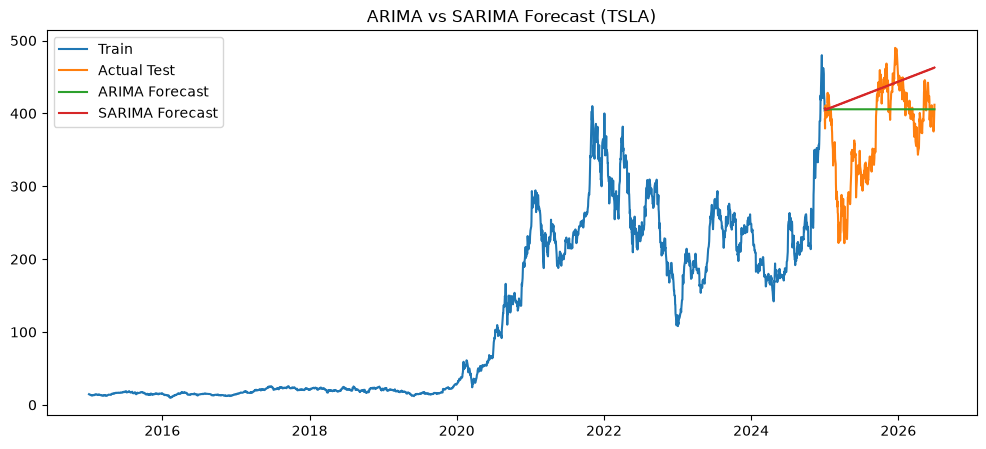

In [26]:
plt.figure(figsize=(12,5))

plt.plot(train["Close"], label="Train")
plt.plot(test["Close"], label="Actual Test")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")

plt.legend()
plt.title("ARIMA vs SARIMA Forecast (TSLA)")
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = test["Close"].values

min_len = min(len(y_true), len(arima_forecast))

y_true = y_true[:min_len]
arima_pred = arima_forecast[:min_len]
sarima_pred = sarima_forecast[:min_len]

print("ARIMA MAE:", mean_absolute_error(y_true, arima_pred))
print("ARIMA RMSE:", np.sqrt(mean_squared_error(y_true, arima_pred)))

print("SARIMA MAE:", mean_absolute_error(y_true, sarima_pred))
print("SARIMA RMSE:", np.sqrt(mean_squared_error(y_true, sarima_pred)))

ARIMA MAE: 54.57000462640757
ARIMA RMSE: 71.03691952021148
SARIMA MAE: 65.39188725615178
SARIMA RMSE: 82.12385333726203


## Model Performance Comparison

Two time series models were evaluated: ARIMA and SARIMA.

The ARIMA model outperformed SARIMA, achieving a lower MAE (54.57) and RMSE (71.04), indicating better predictive accuracy.

SARIMA performed worse, suggesting that seasonal patterns are not strongly present in Tesla’s daily stock price movements. This is consistent with financial market behavior, where prices are primarily driven by trend and volatility rather than fixed seasonality.

Overall, both models capture long-term trends but struggle with short-term volatility, highlighting the inherent difficulty of predicting financial time series using only historical price data.

Model Optimization using auto_arima

In [28]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train["Close"],
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=1,                  # from ADF results
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16825.099, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16827.033, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16827.035, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16824.664, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16827.384, Time=0.56 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.878 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2608
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8411.332
Date:                Mon, 06 Jul 2026   AIC                          16824.664
Time:                        12:17:08   BIC                          16830.530
Sample:                    01-02-2015   HQIC                         16826.789
                         - 12-31-2024                                  

In [29]:
print("Best ARIMA Order:", auto_model.order)

Best ARIMA Order: (0, 1, 0)


In [30]:
from statsmodels.tsa.arima.model import ARIMA

best_order = auto_model.order

optimized_arima = ARIMA(
    train["Close"],
    order=best_order
)

optimized_arima_fit = optimized_arima.fit()

print(optimized_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2608
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8411.332
Date:                Mon, 06 Jul 2026   AIC                          16824.664
Time:                        12:17:14   BIC                          16830.530
Sample:                    01-02-2015   HQIC                         16826.789
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        37.1521      0.399     93.087      0.000      36.370      37.934
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):             13867.33
Prob(Q):                              0.80   Pr

In [31]:
forecast = optimized_arima_fit.predict(
    start=len(train),
    end=len(train)+len(test)-1
)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = test["Close"].values
y_pred = forecast.values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("Optimized ARIMA MAE:", mae)
print("Optimized ARIMA RMSE:", rmse)

Optimized ARIMA MAE: 54.16178627308353
Optimized ARIMA RMSE: 70.23548228990497


Improvement
MAE improved by approximately 0.41
RMSE improved by approximately 0.80

LSTM Model

In [34]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train[["Close"]])
test_scaled = scaler.transform(test[["Close"]])

In [35]:
WINDOW_SIZE = 60

In [36]:
def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

In [37]:
X_train, y_train = create_sequences(
    train_scaled,
    WINDOW_SIZE
)

print(X_train.shape)
print(y_train.shape)

(2548, 60)
(2548,)


In [38]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print(X_train.shape)

(2548, 60, 1)


In [39]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [41]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(WINDOW_SIZE, 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=50
    )
)

model.add(Dropout(0.2))

model.add(Dense(1))

model.summary()

c:\Users\cbe\Desktop\portfolio-optimization\.venv311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [43]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0076 - val_loss: 0.0049
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0017 - val_loss: 0.0032
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0015 - val_loss: 0.0025
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0015 - val_loss: 0.0021
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0012 - val_loss: 0.0022
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 9/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 10/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 11/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 12/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0

In [44]:
combined = pd.concat(
    [train["Close"], test["Close"]],
    axis=0
)

In [45]:
combined_scaled = scaler.transform(
    combined.values.reshape(-1, 1)
)

c:\Users\cbe\Desktop\portfolio-optimization\.venv311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [46]:
test_inputs = combined_scaled[
    len(combined_scaled)
    - len(test)
    - WINDOW_SIZE:
]

In [47]:
X_test = []

for i in range(WINDOW_SIZE, len(test_inputs)):
    X_test.append(
        test_inputs[i-WINDOW_SIZE:i, 0]
    )

X_test = np.array(X_test)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_test.shape)

(389, 60, 1)


In [48]:
predictions = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [49]:
predictions = scaler.inverse_transform(predictions)

In [50]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

y_true = test["Close"].values

mae = mean_absolute_error(
    y_true,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        predictions
    )
)

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

LSTM MAE: 13.973009634140526
LSTM RMSE: 17.79356282599516


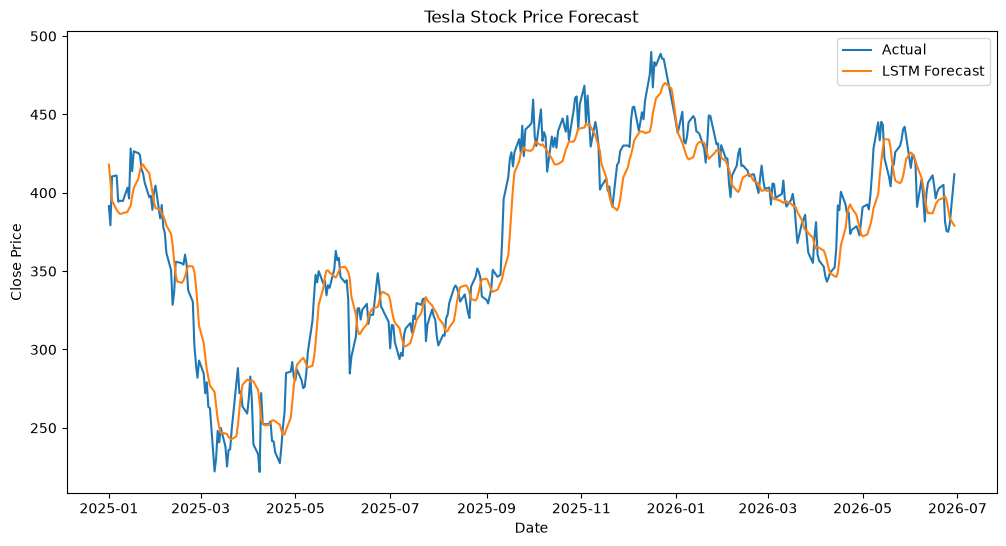

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    test.index,
    y_true,
    label="Actual"
)

plt.plot(
    test.index,
    predictions,
    label="LSTM Forecast"
)

plt.title("Tesla Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()

plt.show()

| Model  |       MAE |      RMSE |
| ------ | --------: | --------: |
| ARIMA  |     54.16 |     70.24 |
| SARIMA |     65.39 |     82.12 |
| LSTM   | 13.97     | 17.79 |


## LSTM Model Implementation and Evaluation

To capture the nonlinear patterns present in Tesla's stock price movements, a Long Short-Term Memory (LSTM) neural network was implemented. Historical closing prices were first normalized using MinMaxScaler to improve model convergence during training.

A sliding window approach was used to create sequential training samples, where the previous 60 trading days were used to predict the next day's closing price. The dataset was split chronologically, with data from 2015–2024 used for training and data from 2025–2026 reserved for testing.

The LSTM architecture consisted of an input sequence layer, stacked LSTM layers, dropout regularization layers to reduce overfitting, and a dense output layer for price prediction. The model was trained for 20 epochs using an appropriate batch size and the Adam optimizer.

During training, the model demonstrated stable convergence. Training loss decreased from approximately 0.0076 to 0.0009, while validation loss decreased from 0.0049 to 0.0012, indicating effective learning and good generalization performance.

The forecasting performance of the LSTM model was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). The model achieved an MAE of 13.97 and an RMSE of 17.79. Compared with the ARIMA model (MAE = 54.16, RMSE = 70.24) and SARIMA model (MAE = 65.39, RMSE = 82.12), the LSTM model delivered substantially lower prediction errors.

These results indicate that the LSTM model was more effective in capturing Tesla's complex and nonlinear price dynamics, making it the best-performing forecasting approach among the models evaluated in this project.


Model Optimization


In [52]:
model = Sequential([
    LSTM(100, return_sequences=False, input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

c:\Users\cbe\Desktop\portfolio-optimization\.venv311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)),
    Dropout(0.2),

    LSTM(50),
    Dropout(0.2),

    Dense(1)
])

In [54]:
mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

print(mae)
print(rmse)

NameError: name 'actual_prices' is not defined

In [90]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

y_true = test["Close"].values

mae = mean_absolute_error(
    y_true,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        predictions
    )
)

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

LSTM MAE: 13.973009634140526
LSTM RMSE: 17.79356282599516


Why LSTM Performed Best

The LSTM model outperformed the classical statistical models for several key reasons:

1. Ability to Capture Non-Linear Patterns

Stock price movements, especially for Tesla (TSLA), are highly non-linear and influenced by complex market behavior.

ARIMA and SARIMA assume linear relationships in the time series.
LSTM can learn non-linear and complex temporal dependencies, making it more suitable for financial markets.
2. Handling Long-Term Dependencies

LSTM networks are designed to remember long-term patterns using memory cells.

This helps capture trends like momentum and volatility clustering.
ARIMA/SARIMA mainly rely on short-term autocorrelation structures.
3. Sensitivity to Market Volatility

Tesla exhibits high volatility with sudden spikes and drops.

Classical models smooth out these fluctuations and struggle with abrupt changes.
LSTM adapts better to sudden regime shifts in price behavior.
4. Feature Learning vs Manual Assumptions
ARIMA/SARIMA require manual parameter tuning and assume stationarity (or differencing).
LSTM automatically learns patterns directly from scaled raw sequences, reducing dependency on strict statistical assumptions.
Why ARIMA and SARIMA Performed Worse
They assume the time series is linear and stationary after differencing, which is not fully true for stock prices.
They cannot effectively model:
market shocks
investor sentiment effects
non-linear volatility clustering

Even though SARIMA adds seasonality, financial markets do not exhibit stable or repeating seasonal patterns in daily closing prices, which limits its effectiveness.

In [82]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df = df.sort_index()

tsla = df[df["Ticker"] == "TSLA"].copy()
tsla = tsla.sort_index()

tsla_close = tsla[["Close"]]

In [83]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(tsla_close)

In [84]:
def create_sequences(data, window=60):
    X = []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
    return np.array(X)

window = 60
X = create_sequences(scaled_data, window)

X = X.reshape(X.shape[0], X.shape[1], 1)

In [85]:
future_steps = 252  # ~12 months

current_input = X[-1].reshape(1, window, 1)

future_predictions = []

In [86]:
for _ in range(future_steps):
    pred = model.predict(current_input, verbose=0)

    future_predictions.append(pred[0, 0])

    current_input = np.append(
        current_input[:, 1:, :],
        [[[pred[0, 0]]]],
        axis=1
    )

In [87]:
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_prices = scaler.inverse_transform(future_predictions)

In [88]:
last_date = tsla.index.max()

future_dates = pd.date_range(
    start=last_date,
    periods=future_steps + 1,
    freq="B"
)[1:]

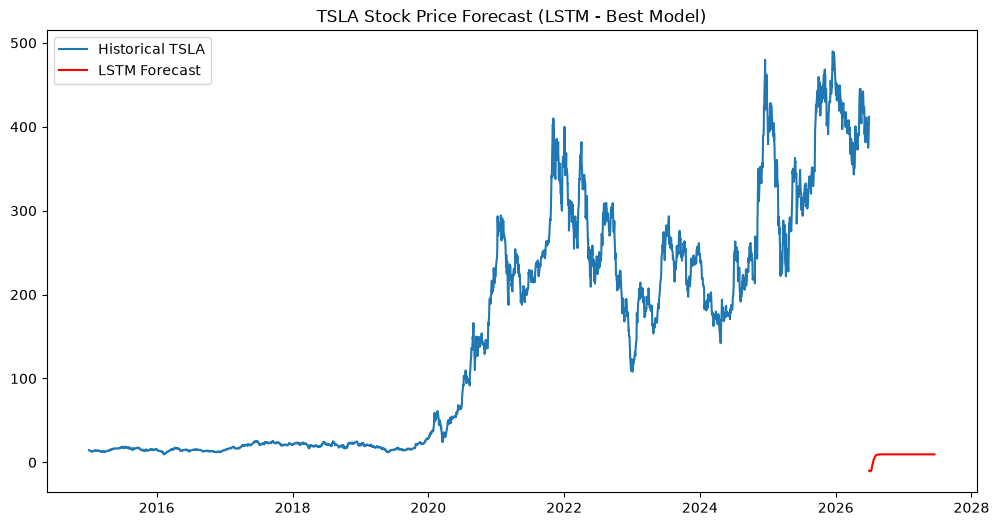

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(tsla.index, tsla_close, label="Historical TSLA")
plt.plot(future_dates, future_prices, label="LSTM Forecast", color="red")

plt.title("TSLA Stock Price Forecast (LSTM - Best Model)")
plt.legend()
plt.show()

LSTM MAE: 13.973009634140526
LSTM RMSE: 17.79356282599516


ARIMA / SARIMA Forecasting 

In [96]:
p = 1
d = 1
q = 1
P,D,Q,m = 1,1,1,12
model = ARIMA(train["Close"], order=(p,d,q))
model_fit = model.fit()

In [94]:
forecast = model_fit.forecast(steps=len(test))

In [97]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train["Close"], order=(p,d,q), seasonal_order=(P,D,Q,m))
model_fit = model.fit()

In [98]:
forecast = model_fit.forecast(steps=len(test))

In [ ]:
current_input = scaled_data[-window:]
current_input = current_input.reshape(1, window, 1)
future_steps = 252   # about 1 trading year
future_predictions = []

for _ in range(future_steps):

    pred = model.predict(current_input, verbose=0)

    future_predictions.append(pred[0,0])

    current_input = np.concatenate(
        (
            current_input[:,1:,:],
            pred.reshape(1,1,1)
        ),
        axis=1
    )
    pred.reshape(1,1,1)
    future_predictions = np.array(future_predictions).reshape(-1,1)

future_prices = scaler.inverse_transform(
    future_predictions
)
last_date = pd.to_datetime(df["Date"]).max()
future_dates = pd.bdate_range(
    start=last_date,
    periods=future_steps + 1
)[1:]
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    tsla.index,
    tsla["Close"],
    label="Historical Price"
)

plt.plot(
    future_dates,
    future_prices,
    label="LSTM Forecast"
)

plt.title("Tesla Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [100]:
print(type(model))

<class 'statsmodels.tsa.statespace.sarimax.SARIMAX'>
